# All-to-All MFPT: Simulation vs Julia Theory

This notebook compares mean first-passage times (MFPT) to consensus using:
- Monte Carlo simulation from the Julia API
- Analytical Julia formulas (ported from `voter_model` and exposed in `VoterResetting`)

The sweep spans ranges of `N`, `m0`, and `r`.

In [5]:
using Random
using Statistics
using Printf
using Plots

candidates = [abspath(pwd()), abspath(joinpath(pwd(), "..")), abspath(joinpath(pwd(), "..", ".."))]
project_root = nothing
for p in candidates
    if isfile(joinpath(p, "src", "VoterResetting.jl"))
        global project_root = p
        break
    end
end
project_root === nothing && error("Could not locate project root containing src/VoterResetting.jl from pwd=$(pwd())")

include(joinpath(project_root, "src", "VoterResetting.jl"))
const VR = VoterResetting

Main.VoterResetting

In [6]:
function mfpt_sweep_all_to_all(
    N_values, m0_values, r_values;
    nsamples=400,
    M=600,
    seed=1234,
    use_python_rate_scaling=true,
    first_point_refine_nsamples=5000,
    first_point_refine_M=2000,
    verbose=true,
)
    Random.seed!(seed)
    rows = NamedTuple[]

    total = length(N_values) * length(m0_values) * length(r_values)
    done = 0

    for N in N_values
        for m0 in m0_values
            for r in r_values
                # Theory in this notebook follows the Python convention: mean_fpt scales r internally as r/N.
                # To compare apples-to-apples, use r_sim = r/N in Gillespie when this flag is true.
                r_sim = use_python_rate_scaling ? (r / N) : r

                params = VR.AllToAllParams(N, r_sim, m0)
                sim = VR.first_passage_time_all_to_all(
                    params;
                    consensus_type=:either,
                    nsamples=nsamples,
                    reset=VR.delta_reset(m0),
                )

                th = VR.mean_fpt(N, m0, r; M=M)
                sim_stderr = sim.std_fpt / sqrt(nsamples)
                rel_err = (sim.mean_fpt - th) / th
                zscore = (sim.mean_fpt - th) / max(sim_stderr, 1e-12)

                # Optional expensive check for the first sweep point (often the noisiest/slowest).
                if done == 0 && first_point_refine_nsamples > nsamples
                    sim_ref = VR.first_passage_time_all_to_all(
                        params;
                        consensus_type=:either,
                        nsamples=first_point_refine_nsamples,
                        reset=VR.delta_reset(m0),
                    )
                    th_ref = VR.mean_fpt(N, m0, r; M=first_point_refine_M)
                    sim_stderr_ref = sim_ref.std_fpt / sqrt(first_point_refine_nsamples)
                    rel_err_ref = (sim_ref.mean_fpt - th_ref) / th_ref
                    zscore_ref = (sim_ref.mean_fpt - th_ref) / max(sim_stderr_ref, 1e-12)

                    push!(rows, (
                        N=N,
                        m0=m0,
                        r=r,
                        r_sim=r_sim,
                        nsamples=first_point_refine_nsamples,
                        M=first_point_refine_M,
                        mfpt_sim=sim_ref.mean_fpt,
                        mfpt_theory=th_ref,
                        std_sim=sim_ref.std_fpt,
                        stderr_sim=sim_stderr_ref,
                        rel_err=rel_err_ref,
                        zscore=zscore_ref,
                        refined=true,
                    ))

                    done += 1
                    if verbose
                        @printf("[%d/%d][refined] N=%d, m0=%.3f, r=%.3f, r_sim=%.6g -> sim=%.5g ± %.3g, theory=%.5g, rel_err=%.3e, z=%.2f\n",
                            done, total, N, m0, r, r_sim, sim_ref.mean_fpt, sim_stderr_ref, th_ref, rel_err_ref, zscore_ref)
                    end
                    continue
                end

                push!(rows, (
                    N=N,
                    m0=m0,
                    r=r,
                    r_sim=r_sim,
                    nsamples=nsamples,
                    M=M,
                    mfpt_sim=sim.mean_fpt,
                    mfpt_theory=th,
                    std_sim=sim.std_fpt,
                    stderr_sim=sim_stderr,
                    rel_err=rel_err,
                    zscore=zscore,
                    refined=false,
                ))

                done += 1
                if verbose
                    @printf("[%d/%d] N=%d, m0=%.3f, r=%.3f, r_sim=%.6g -> sim=%.5g ± %.3g, theory=%.5g, rel_err=%.3e, z=%.2f\n",
                        done, total, N, m0, r, r_sim, sim.mean_fpt, sim_stderr, th, rel_err, zscore)
                end
            end
        end
    end

    return rows
end

mfpt_sweep_all_to_all (generic function with 1 method)

In [7]:
N_values = [200, 500, 1000, 2000, 5000, 10000]
m0_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
r_values = [0]#[0.1, 0.3, 0.7, 1.5, 3.0, 7.0, 15.0, 30.0]

# Fast baseline sweep + expensive first-point refinement for diagnostics.
nsamples = 400
M = 600

rows = mfpt_sweep_all_to_all(
    N_values, m0_values, r_values;
    nsamples=nsamples,
    M=M,
    seed=42,
    use_python_rate_scaling=true,
    first_point_refine_nsamples=5000,
    first_point_refine_M=2000,
    verbose=true,
)
println("Computed $(length(rows)) parameter points.")

[1/60][refined] N=200, m0=0.000, r=0.000, r_sim=0 -> sim=136.12 ± 1.41, theory=140.4, rel_err=-3.049e-02, z=-3.05
[2/60] N=200, m0=0.100, r=0.000, r_sim=0 -> sim=138.22 ± 5.44, theory=139.71, rel_err=-1.067e-02, z=-0.27
[3/60] N=200, m0=0.200, r=0.000, r_sim=0 -> sim=131.32 ± 4.85, theory=131.59, rel_err=-2.047e-03, z=-0.06
[4/60] N=200, m0=0.300, r=0.000, r_sim=0 -> sim=130.12 ± 5.5, theory=130.13, rel_err=-1.451e-04, z=-0.00
[5/60] N=200, m0=0.400, r=0.000, r_sim=0 -> sim=115.68 ± 4.64, theory=120.15, rel_err=-3.719e-02, z=-0.96
[6/60] N=200, m0=0.500, r=0.000, r_sim=0 -> sim=114.05 ± 5.15, theory=115.22, rel_err=-1.018e-02, z=-0.23
[7/60] N=200, m0=0.600, r=0.000, r_sim=0 -> sim=101.35 ± 5.32, theory=102.6, rel_err=-1.216e-02, z=-0.23
[8/60] N=200, m0=0.700, r=0.000, r_sim=0 -> sim=97.784 ± 5.1, theory=85.897, rel_err=1.384e-01, z=2.33
[9/60] N=200, m0=0.800, r=0.000, r_sim=0 -> sim=59.77 ± 3.9, theory=65.915, rel_err=-9.323e-02, z=-1.58
[10/60] N=200, m0=0.900, r=0.000, r_sim=0 -> 

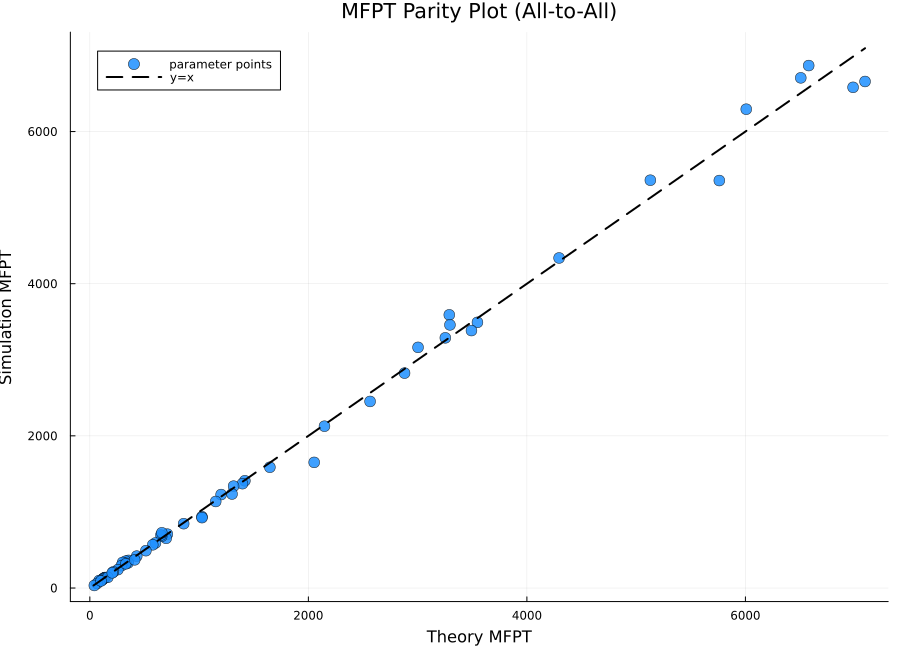

In [8]:
theory = [x.mfpt_theory for x in rows]
sim = [x.mfpt_sim for x in rows]
labels = ["N=$(x.N), m0=$(x.m0), r=$(x.r)" for x in rows]

# Keep only finite positive values for log-log parity plotting.
valid = [isfinite(t) && isfinite(s) && t > 0 && s > 0 for (t, s) in zip(theory, sim)]
theory_v = theory[valid]
sim_v = sim[valid]
labels_v = labels[valid]

isempty(theory_v) && error("No positive finite points available for log-log parity plot.")

lo = min(minimum(theory_v), minimum(sim_v))
hi = max(maximum(theory_v), maximum(sim_v))

p_parity = scatter(
    theory_v, sim_v;
    # xscale=:log10,
    # yscale=:log10,
    xlabel="Theory MFPT",
    ylabel="Simulation MFPT",
    title="MFPT Parity Plot (All-to-All)",
    markersize=6,
    alpha=0.85,
    label="parameter points",
    legend=:topleft,
    markerstrokewidth=0.4,
    markerstrokealpha=0.6,
    color=:dodgerblue,
    size=(900, 650),
)
plot!(p_parity, [lo, hi], [lo, hi]; lw=2, ls=:dash, color=:black, label="y=x")

display(p_parity)